In [1]:
!pip install memory-profiler evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [5]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [6]:
df = df.dropna()

In [7]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [8]:
target = df.columns[-1]  # last column as target

X = df.drop(target, axis=1)
y = df[target]

In [9]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
model.fit(X_train, y_train)
end = time.time()

print("Training Time:", end - start)

Training Time: 0.32159852981567383


In [12]:
scores = cross_val_score(model, X, y, cv=5)

print("CV Mean:", scores.mean())
print("CV Std Dev:", scores.std())

CV Mean: 0.9808333333333333
CV Std Dev: 0.0033333333333333214


In [13]:
start = time.time()
y_pred = model.predict(X_test)
end = time.time()

print("Prediction Time per sample:", (end-start)/len(X_test))

Prediction Time per sample: 5.175968011220296e-05


In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9791666666666666
Precision: 0.979602510460251
Recall: 0.9791666666666666
F1 Score: 0.9718363032316522
Confusion Matrix:
 [[234   0]
 [  5   1]]


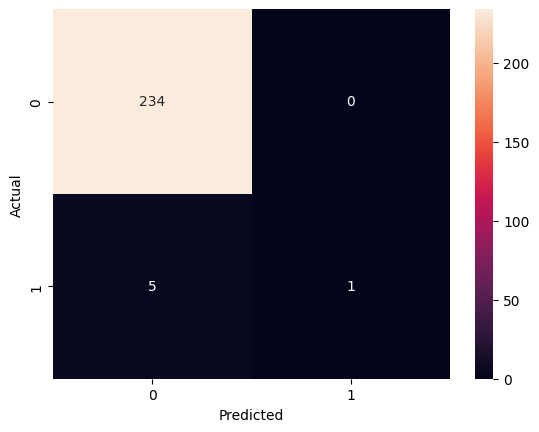

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

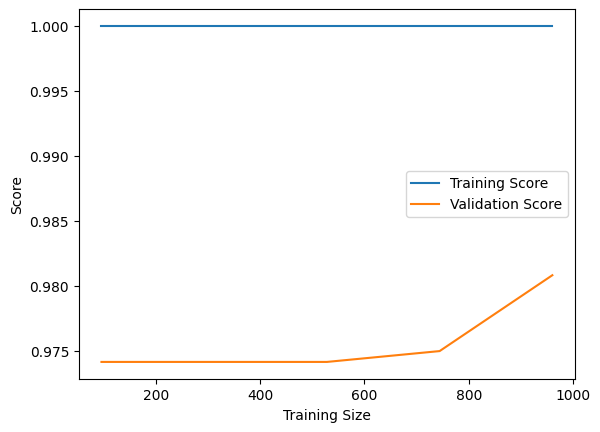

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.legend()
plt.xlabel("Training Size")
plt.ylabel("Score")
plt.show()

In [17]:
model2 = RandomForestClassifier(max_depth=5)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, y_pred2))

New Accuracy: 0.975


In [18]:
from memory_profiler import memory_usage

def train_model():
    model.fit(X_train, y_train)

mem_usage = memory_usage(train_model)
print("Max Memory Usage:", max(mem_usage))

Max Memory Usage: 265.92578125


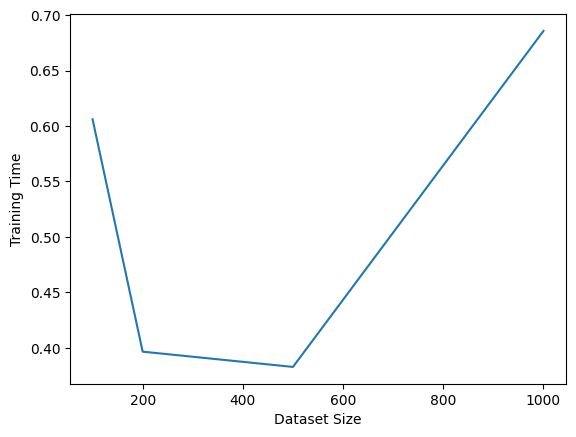

In [19]:
sizes = [100, 200, 500, 1000]
times = []

for size in sizes:
    X_small = X_train[:size]
    y_small = y_train[:size]

    start = time.time()
    model.fit(X_small, y_small)
    times.append(time.time() - start)

plt.plot(sizes, times)
plt.xlabel("Dataset Size")
plt.ylabel("Training Time")
plt.show()

In [21]:
import evaluate

metric = evaluate.load("accuracy")
metric.compute(predictions=y_pred, references=y_test.tolist())

{'accuracy': 0.9791666666666666}